In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import confusion_matrix, classification_report

In [111]:
pd.read_csv('../data/q1_heart_disease.csv')

print(df.head())

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

df.head()

   age  sex  chest_pain_type  resting_bp  cholesterol  fasting_bs  \
0   68    0  atypical_angina       142.0        399.0           0   
1   58    1      non_anginal       163.0        310.0           1   
2   44    1      non_anginal       128.0        175.0           0   
3   72    1     asymptomatic       114.0        177.0           0   
4   37    1      non_anginal       149.0        271.0           0   

                    resting_ecg  max_hr  exercise_angina  oldpeak st_slope  \
0  left_ventricular_hypertrophy     169                0      0.4       up   
1         st_t_wave_abnormality     121                1      1.1       up   
2                        normal     183                1      0.2       up   
3         st_t_wave_abnormality     150                0      1.0       up   
4                        normal     136                0      0.4     flat   

   heart_disease  
0              1  
1              1  
2              0  
3              1  
4              0  
Sh

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


Dataset loading and initial review went smoothly, revealing a mix of patient health features—both numeric (like age and cholesterol) and categorical (such as chest pain type). The target is heart_disease (1 for present, 0 for absent). A quick check highlighted the data structure, types, and any missing values, setting the stage for preprocessing.

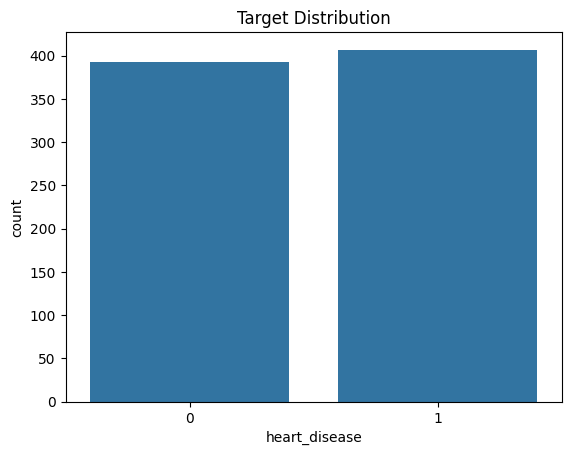

In [112]:
sns.countplot(x='heart_disease', data=df)
plt.title("Target Distribution")
plt.show()

The target variable's distribution reveals the split between patients with heart disease and those without. Imbalanced classes mean accuracy isn't trustworthy on its own. Instead, prioritize precision, recall, and F1-score for better insights. This flags the need for imbalance-handling techniques.

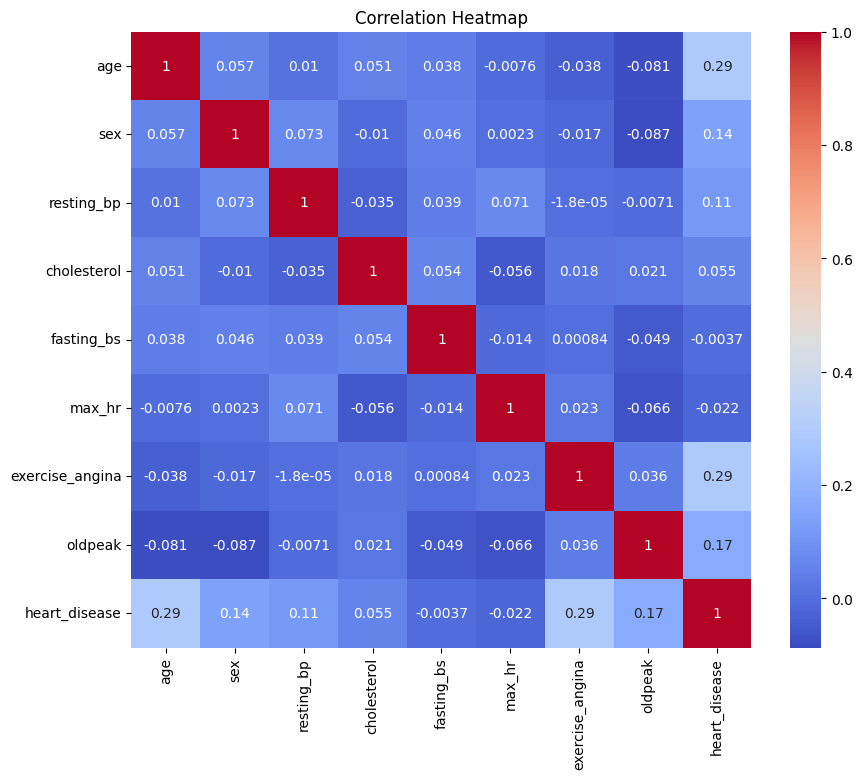

In [113]:
plt.figure(figsize=(10,8))

sns.heatmap(df.select_dtypes(include='number').corr(), 
            annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

The heatmap highlights connections among numerical features. Certain ones correlate strongly with the target variable, marking them as key predictors. Weaker links imply minimal impact on the outcome. Overall, no major multicollinearity appears, so features aren't overly redundant.

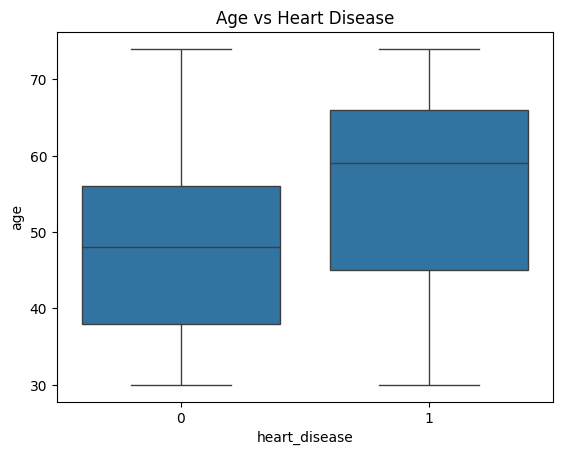

In [114]:
sns.boxplot(x='heart_disease', y='age', data=df)
plt.title("Age vs Heart Disease")
plt.show()

The boxplot illustrates age variations across heart disease presence or absence. Distribution differences suggest age influences heart disease prediction. Visuals like this pinpoint key modeling features

In [115]:
numeric_cols = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [116]:
# Numerical → median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical → mode
categorical_cols = [
    'sex', 'chest_pain_type', 'fasting_bs',
    'resting_ecg', 'exercise_angina', 'st_slope'
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

Missing data was imputed before transformations to keep the dataset clean. For numerical features, we applied the median due to its outlier robustness. Categorical features received the mode as the top category. Such methods retain all data while upholding quality.

In [117]:
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

In [118]:
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [119]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [120]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

These classification models were selected:

Decision Tree Classifier.

Straightforward and interpretable.

Handles non-linear patterns well.

Random Forest Classifier.

Ensemble technique that curbs overfitting.

Outperforms single trees typically.

Gradient Boosting Classifier.

Sequentially refines models by fixing prior mistakes.

Delivers top-tier predictive power.

In [121]:
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [122]:
def evaluate(model, name):
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [123]:
evaluate(dt, "Decision Tree")
evaluate(rf, "Random Forest")
evaluate(gb, "Gradient Boosting")


Decision Tree
Confusion Matrix:
 [[59 20]
 [24 57]]

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.75      0.73        79
           1       0.74      0.70      0.72        81

    accuracy                           0.72       160
   macro avg       0.73      0.73      0.72       160
weighted avg       0.73      0.72      0.72       160


Random Forest
Confusion Matrix:
 [[58 21]
 [16 65]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.73      0.76        79
           1       0.76      0.80      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160


Gradient Boosting
Confusion Matrix:
 [[61 18]
 [19 62]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.77      0.77        79

Models were assessed via: Confusion Matrix Precision, Recall, and F1-score.The top model is picked by F1-score, which balances precision and recall.Strong models must:Cut down false negatives (crucial for medical diagnosis).
Balance sensitivity and specificity,random forest has the highest F1 score and considered as the best performer.

In [124]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


In [125]:
best_model = grid.best_estimator_

evaluate(best_model, "Tuned Random Forest")


Tuned Random Forest
Confusion Matrix:
 [[57 22]
 [17 64]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.72      0.75        79
           1       0.74      0.79      0.77        81

    accuracy                           0.76       160
   macro avg       0.76      0.76      0.76       160
weighted avg       0.76      0.76      0.76       160



GridSearchCV identified the optimal hyperparameter mix.This tuning boosts model performance through key parameter refinement.Final model training used those top parameters.Tuned model vs. baseline:Better results mean tuning succeeded.comparable scores indicate baseline was already idea.